# Cohens d vs MFPT threshold analysis

Compute per-mutant mean abs Cohens d between folded/unfolded descriptors and correlate with log(MFPT_WT / MFPT).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
repo_root = cwd.parent.parent
sys.path.insert(0, str(repo_root / 'src'))

from common.colvar_utils import read_colvar_header_names, load_colvar
from common.consts import res_colors, long_to_short
from common.hlda_utils import bin_sufficient_stats, aggregate_moments, centers_from_edges
from common.utils import collect_df, load_lambda_grid
from common.plot_utils import scatter_with_labels
from paper.style_utils import set_paper_style

set_paper_style()
%config InlineBackend.figure_format = 'retina'


In [2]:
data_dir = repo_root / 'data'
traj_dir = data_dir / 'traj'
mfpt_grid_pkl = data_dir / 'mfpt_all_thresholds-new-ref.pkl'
mfpt_default_pkl = data_dir / 'mfpt-pace=25000-new-ref.pkl'
lambda_cache = data_dir / 'hlda_lambda_grid.pkl'

mfpt_tables = pd.read_pickle(mfpt_grid_pkl)
mfpt_all = pd.read_pickle(mfpt_default_pkl)
lambda_grid = load_lambda_grid(cache_path=lambda_cache, force=False)

sample_n = 1_000_000
n_bins = 200
rmsd_col = 'rmsd_ca'

In [3]:
stats_cache = {}
for short in sorted(set(long_to_short.values())):
    protein_dir = traj_dir / short
    f_path = protein_dir / 'COLVAR_CV_F'
    uf_path = protein_dir / 'COLVAR_CV_UF'
    names = read_colvar_header_names(f_path)
    desc_cols = [c for c in names if c.startswith('d')]
    usecols = desc_cols + [rmsd_col]
    df_F = load_colvar(f_path, usecols, sample_n)
    df_UF = load_colvar(uf_path, usecols, sample_n)

    eF, cF, sF, S2F = bin_sufficient_stats(df_F, desc_cols, rmsd_col, n_bins)
    eU, cU, sU, S2U = bin_sufficient_stats(df_UF, desc_cols, rmsd_col, n_bins)

    stats_cache[short] = {
        'desc_cols': desc_cols,
        'eF': eF, 'cF': cF, 'sF': sF, 'S2F': S2F,
        'eU': eU, 'cU': cU, 'sU': sU, 'S2U': S2U,
        'cF_cent': centers_from_edges(eF),
        'cU_cent': centers_from_edges(eU),
    }


In [4]:
def edges_from_centers(c):
    c = np.asarray(c, float)
    d = np.diff(c)
    if len(d) == 0:
        return np.array([c[0] - 0.5, c[0] + 0.5])
    edges = np.empty(c.size + 1, float)
    edges[1:-1] = (c[:-1] + c[1:]) / 2
    edges[0] = c[0] - d[0] / 2
    edges[-1] = c[-1] + d[-1] / 2
    return edges


def plot_heatmap_in_ax(ax, df, value_col, title, vmin=0.0, vmax=1.0, cmap='YlOrRd'):
    P = df.pivot(index='tF', columns='tU', values=value_col).sort_index(ascending=True)
    x_centers = P.columns.values.astype(float)
    y_centers = P.index.values.astype(float)
    x_edges = edges_from_centers(x_centers)
    y_edges = edges_from_centers(y_centers)

    im = ax.pcolormesh(
        x_edges, y_edges, P.values,
        vmin=vmin, vmax=vmax, cmap=cmap, shading='flat'
    )

    for i, tF in enumerate(y_centers):
        for j, tU in enumerate(x_centers):
            val = P.iloc[i, j]
            if np.isfinite(val):
                ax.text(tU, tF, f'{val:.2f}', ha='center', va='center', fontsize=6)

    ax.set_xlabel('tU')
    ax.set_ylabel('tF')
    ax.set_title(title, fontsize=9)
    return im


In [5]:
def cohen_d_projected(short, tF, tU):
    stats = stats_cache[short]
    desc_cols = stats['desc_cols']
    mask_F = stats['cF_cent'] <= tF
    muF, covF, nF = aggregate_moments(stats['cF'], stats['sF'], stats['S2F'], mask_F)
    mask_U = stats['cU_cent'] >= tU
    muU, covU, nU = aggregate_moments(stats['cU'], stats['sU'], stats['S2U'], mask_U)

    lam_row = lambda_grid[(lambda_grid['Mutant'] == short) & (lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)].iloc[0]
    weights = lam_row['weights']
    w = np.array([weights[d] for d in desc_cols], float)

    muF_proj = float(w @ muF)
    muU_proj = float(w @ muU)
    varF_proj = float(w.T @ covF @ w)
    varU_proj = float(w.T @ covU @ w)

    pooled = ((nF - 1) * varF_proj + (nU - 1) * varU_proj) / (nF + nU - 2)
    d = (muF_proj - muU_proj) / np.sqrt(pooled)
    return float(abs(d))


In [6]:
mfpt_thresholds = sorted(mfpt_tables.keys())
unique_tf = sorted(lambda_grid['tF'].unique())
unique_tu = sorted(lambda_grid['tU'].unique())
skip_short = set()

cohen_cache = {}
heatmap_results = []
best_rows = []
mean_cache = {}

In [7]:
for thr in mfpt_thresholds:
    rows = []
    for tF in unique_tf:
        for tU in unique_tu:
            if tU <= tF:
                continue
            sub_lam = lambda_grid[(lambda_grid['tF'] == tF) & (lambda_grid['tU'] == tU)]
            df_thr = collect_df(
                mfpt_all,
                mfpt_threshold=float(thr),
                tF=float(tF),
                tU=float(tU),
                lambda_df=sub_lam,
                skip_short=skip_short,
                quiet=True,
            )
            wt_mfpt = float(df_thr.loc['WT', 'mfpt'])
            df_thr['log_mfpt_ratio'] = np.log(wt_mfpt / df_thr['mfpt'])

            def cohen_for_row(row):
                short = row.name
                key = (short, float(tF), float(tU))
                if key not in cohen_cache:
                    cohen_cache[key] = cohen_d_projected(short, float(tF), float(tU))
                return cohen_cache[key]

            df_thr['cohen_d'] = df_thr.apply(cohen_for_row, axis=1)
            rho = df_thr['cohen_d'].corr(df_thr['log_mfpt_ratio'], method='spearman')
            pear = df_thr['cohen_d'].corr(df_thr['log_mfpt_ratio'], method='pearson')
            rows.append({
                'tF': float(tF),
                'tU': float(tU),
                'val': abs(rho) if pd.notna(rho) else np.nan,
                'pear': abs(pear) if pd.notna(pear) else np.nan,
            })
            mean_cache[(float(thr), float(tF), float(tU))] = df_thr
    heatmap_results.append({'thr': float(thr), 'rows': rows})

best_rows = []
for res in heatmap_results:
    df = pd.DataFrame(res['rows']).dropna(subset=['val', 'pear'])
    if df.empty:
        continue
    df = df.copy()
    df['combo'] = 0.5 * (df['val'].astype(float) + df['pear'].astype(float))
    idx = df['combo'].idxmax()
    best = df.loc[idx]
    best_rows.append({
        'thr': res['thr'],
        'tF': best['tF'],
        'tU': best['tU'],
        'val': best['val'],
        'pear': best['pear'],
        'combo': best['combo'],
    })

best_df = pd.DataFrame(best_rows)
best_df


,thr,tF,tU,val,pear,combo
0,0.28,0.29,0.74,0.183784,0.208857,0.196321
1,0.30,0.22,0.30,0.130245,0.147498,0.138871
2,0.32,0.22,0.63,0.145431,0.160483,0.152957
3,0.34,0.22,0.57,0.134620,0.116028,0.125324
4,0.36,0.32,0.35,0.105019,0.210889,0.157954
5,0.38,0.32,0.35,0.138224,0.249401,0.193813
6,0.40,0.18,0.35,0.231660,0.328815,0.280238
7,0.42,0.32,0.63,0.299614,0.244198,0.271906
8,0.44,0.32,0.63,0.314028,0.277635,0.295831
9,0.46,0.32,0.63,0.320463,0.279971,0.300217


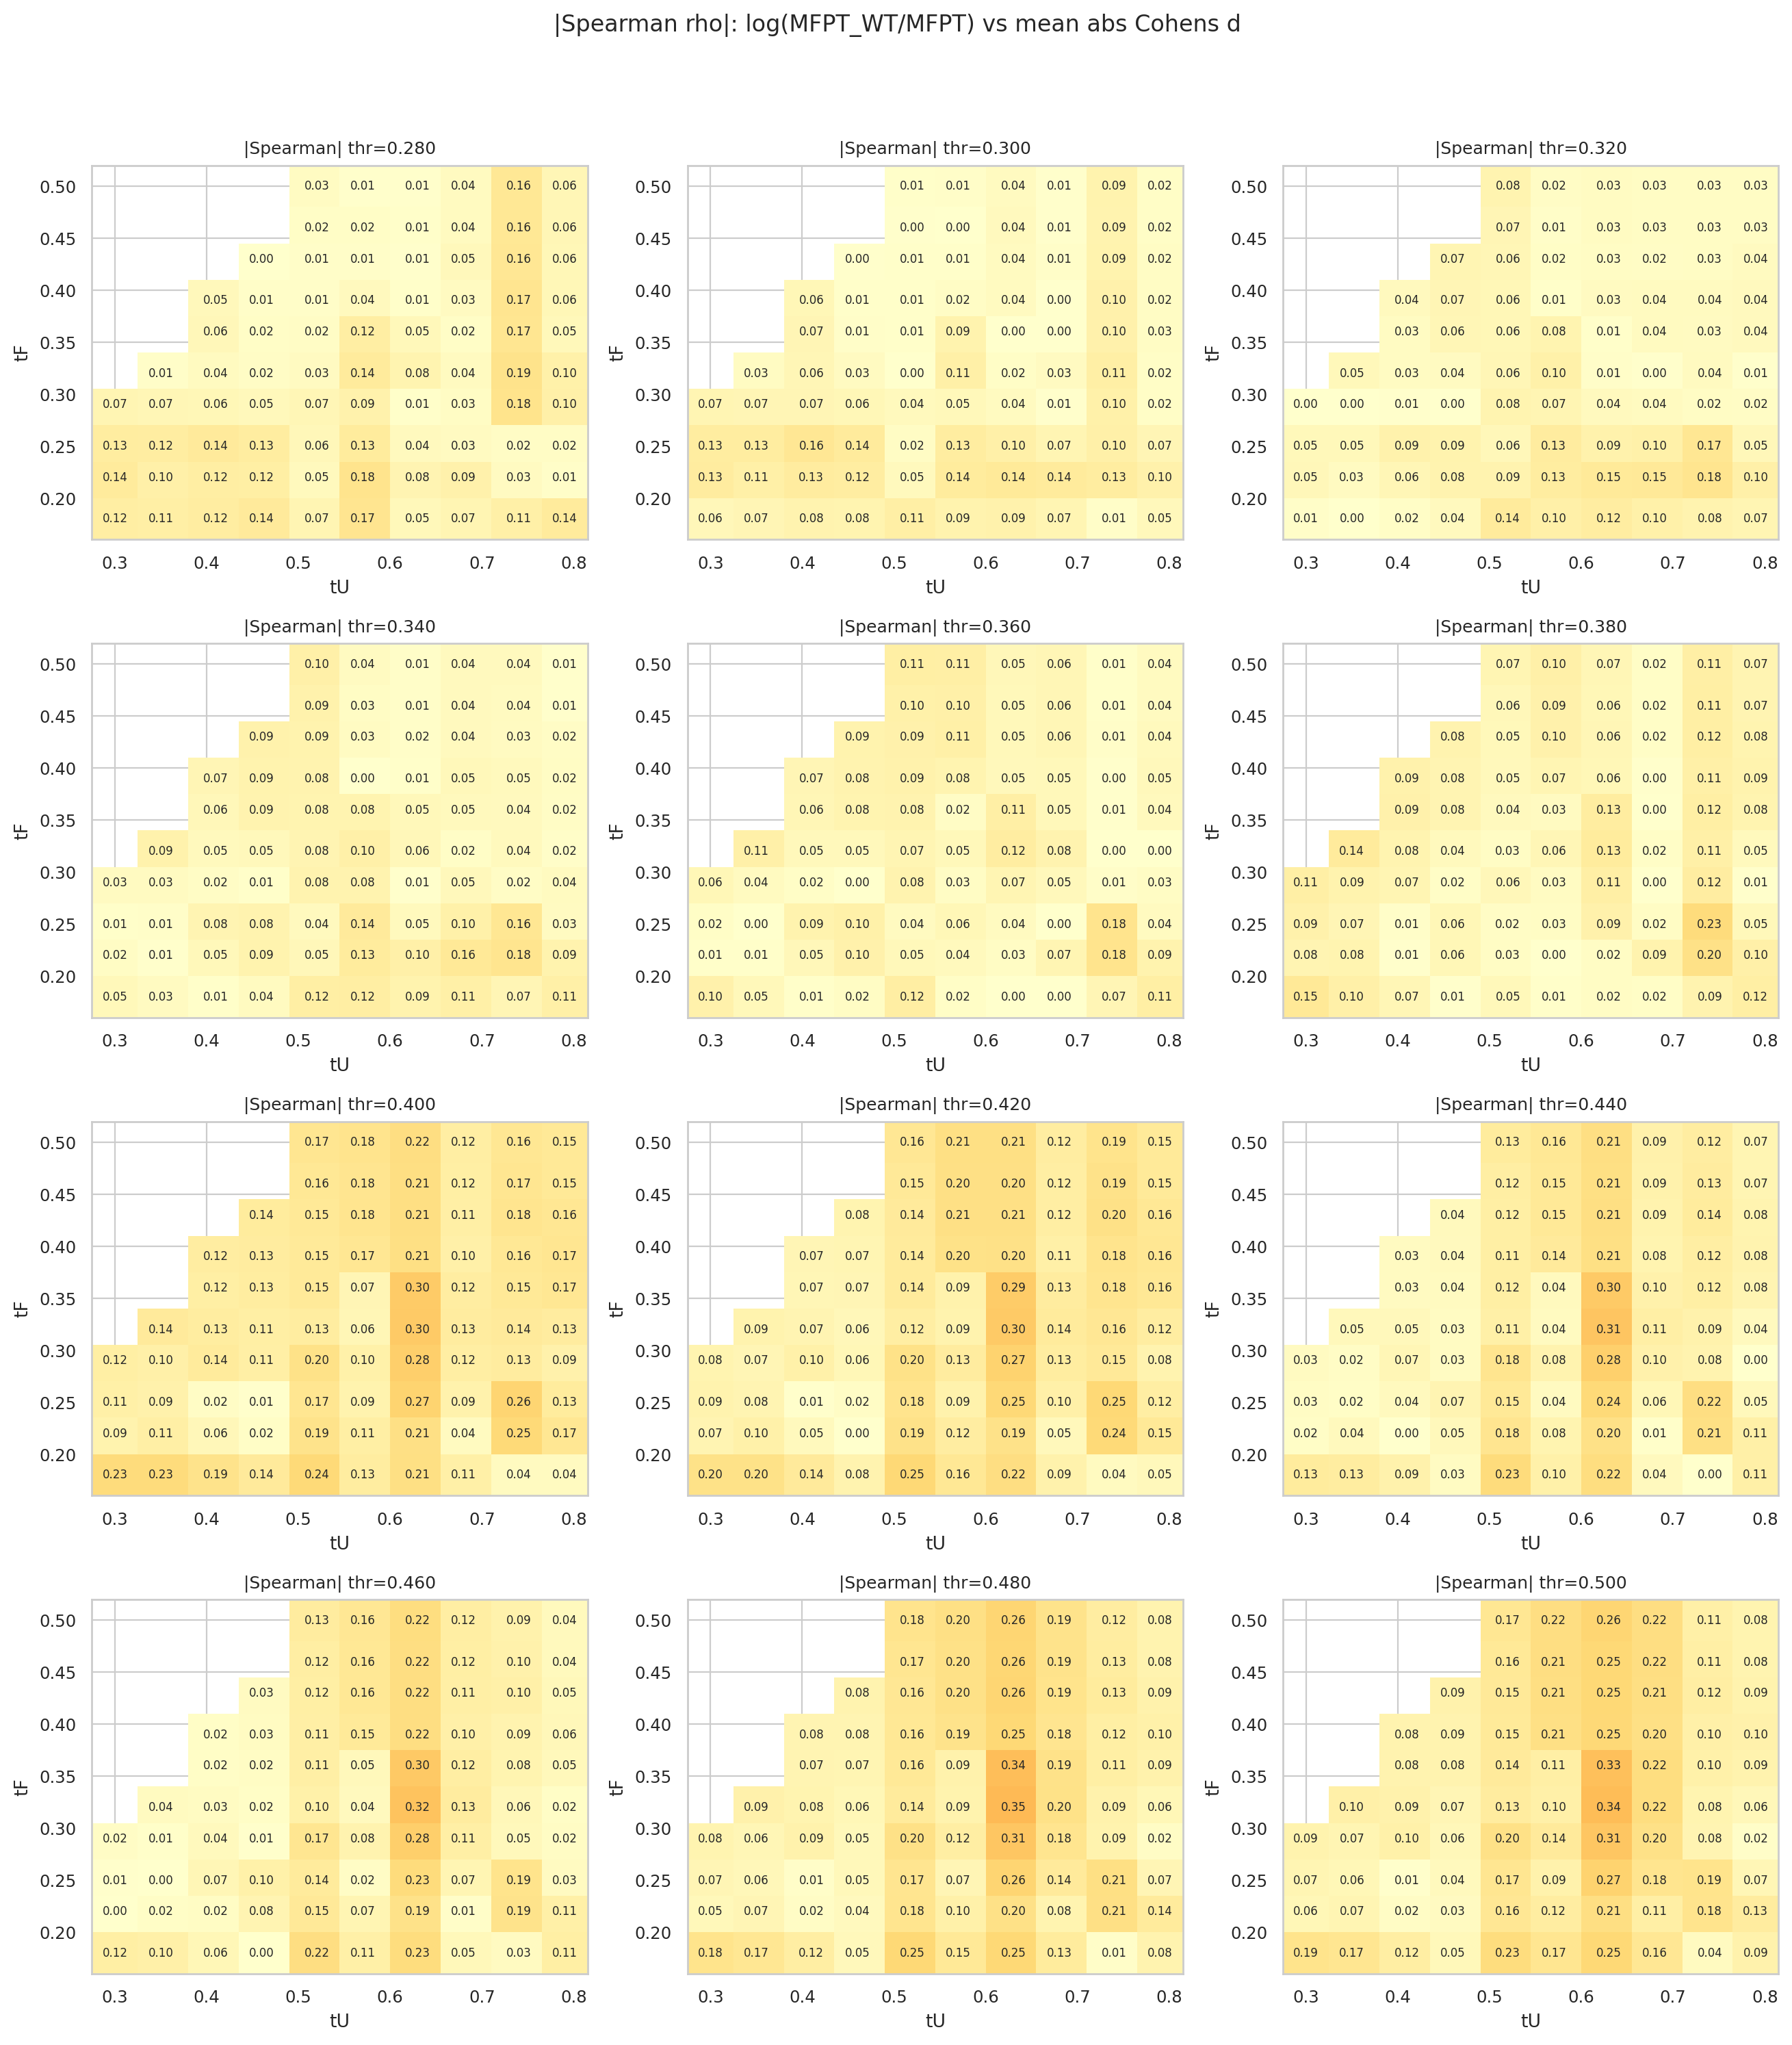

In [8]:
ncols = min(3, len(heatmap_results) if heatmap_results else 1)
nrows = int(np.ceil(len(heatmap_results) / ncols)) if heatmap_results else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)
for ax, res in zip(axes.ravel(), heatmap_results):
    df = pd.DataFrame(res['rows'])
    if df.empty:
        ax.axis('off')
        continue
    plot_heatmap_in_ax(ax, df, 'val', title=f"|Spearman| thr={res['thr']:.3f}", vmin=0, vmax=1)
for ax in axes.ravel()[len(heatmap_results):]:
    ax.axis('off')
fig.suptitle("|Spearman rho|: log(MFPT_WT/MFPT) vs mean abs Cohens d", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

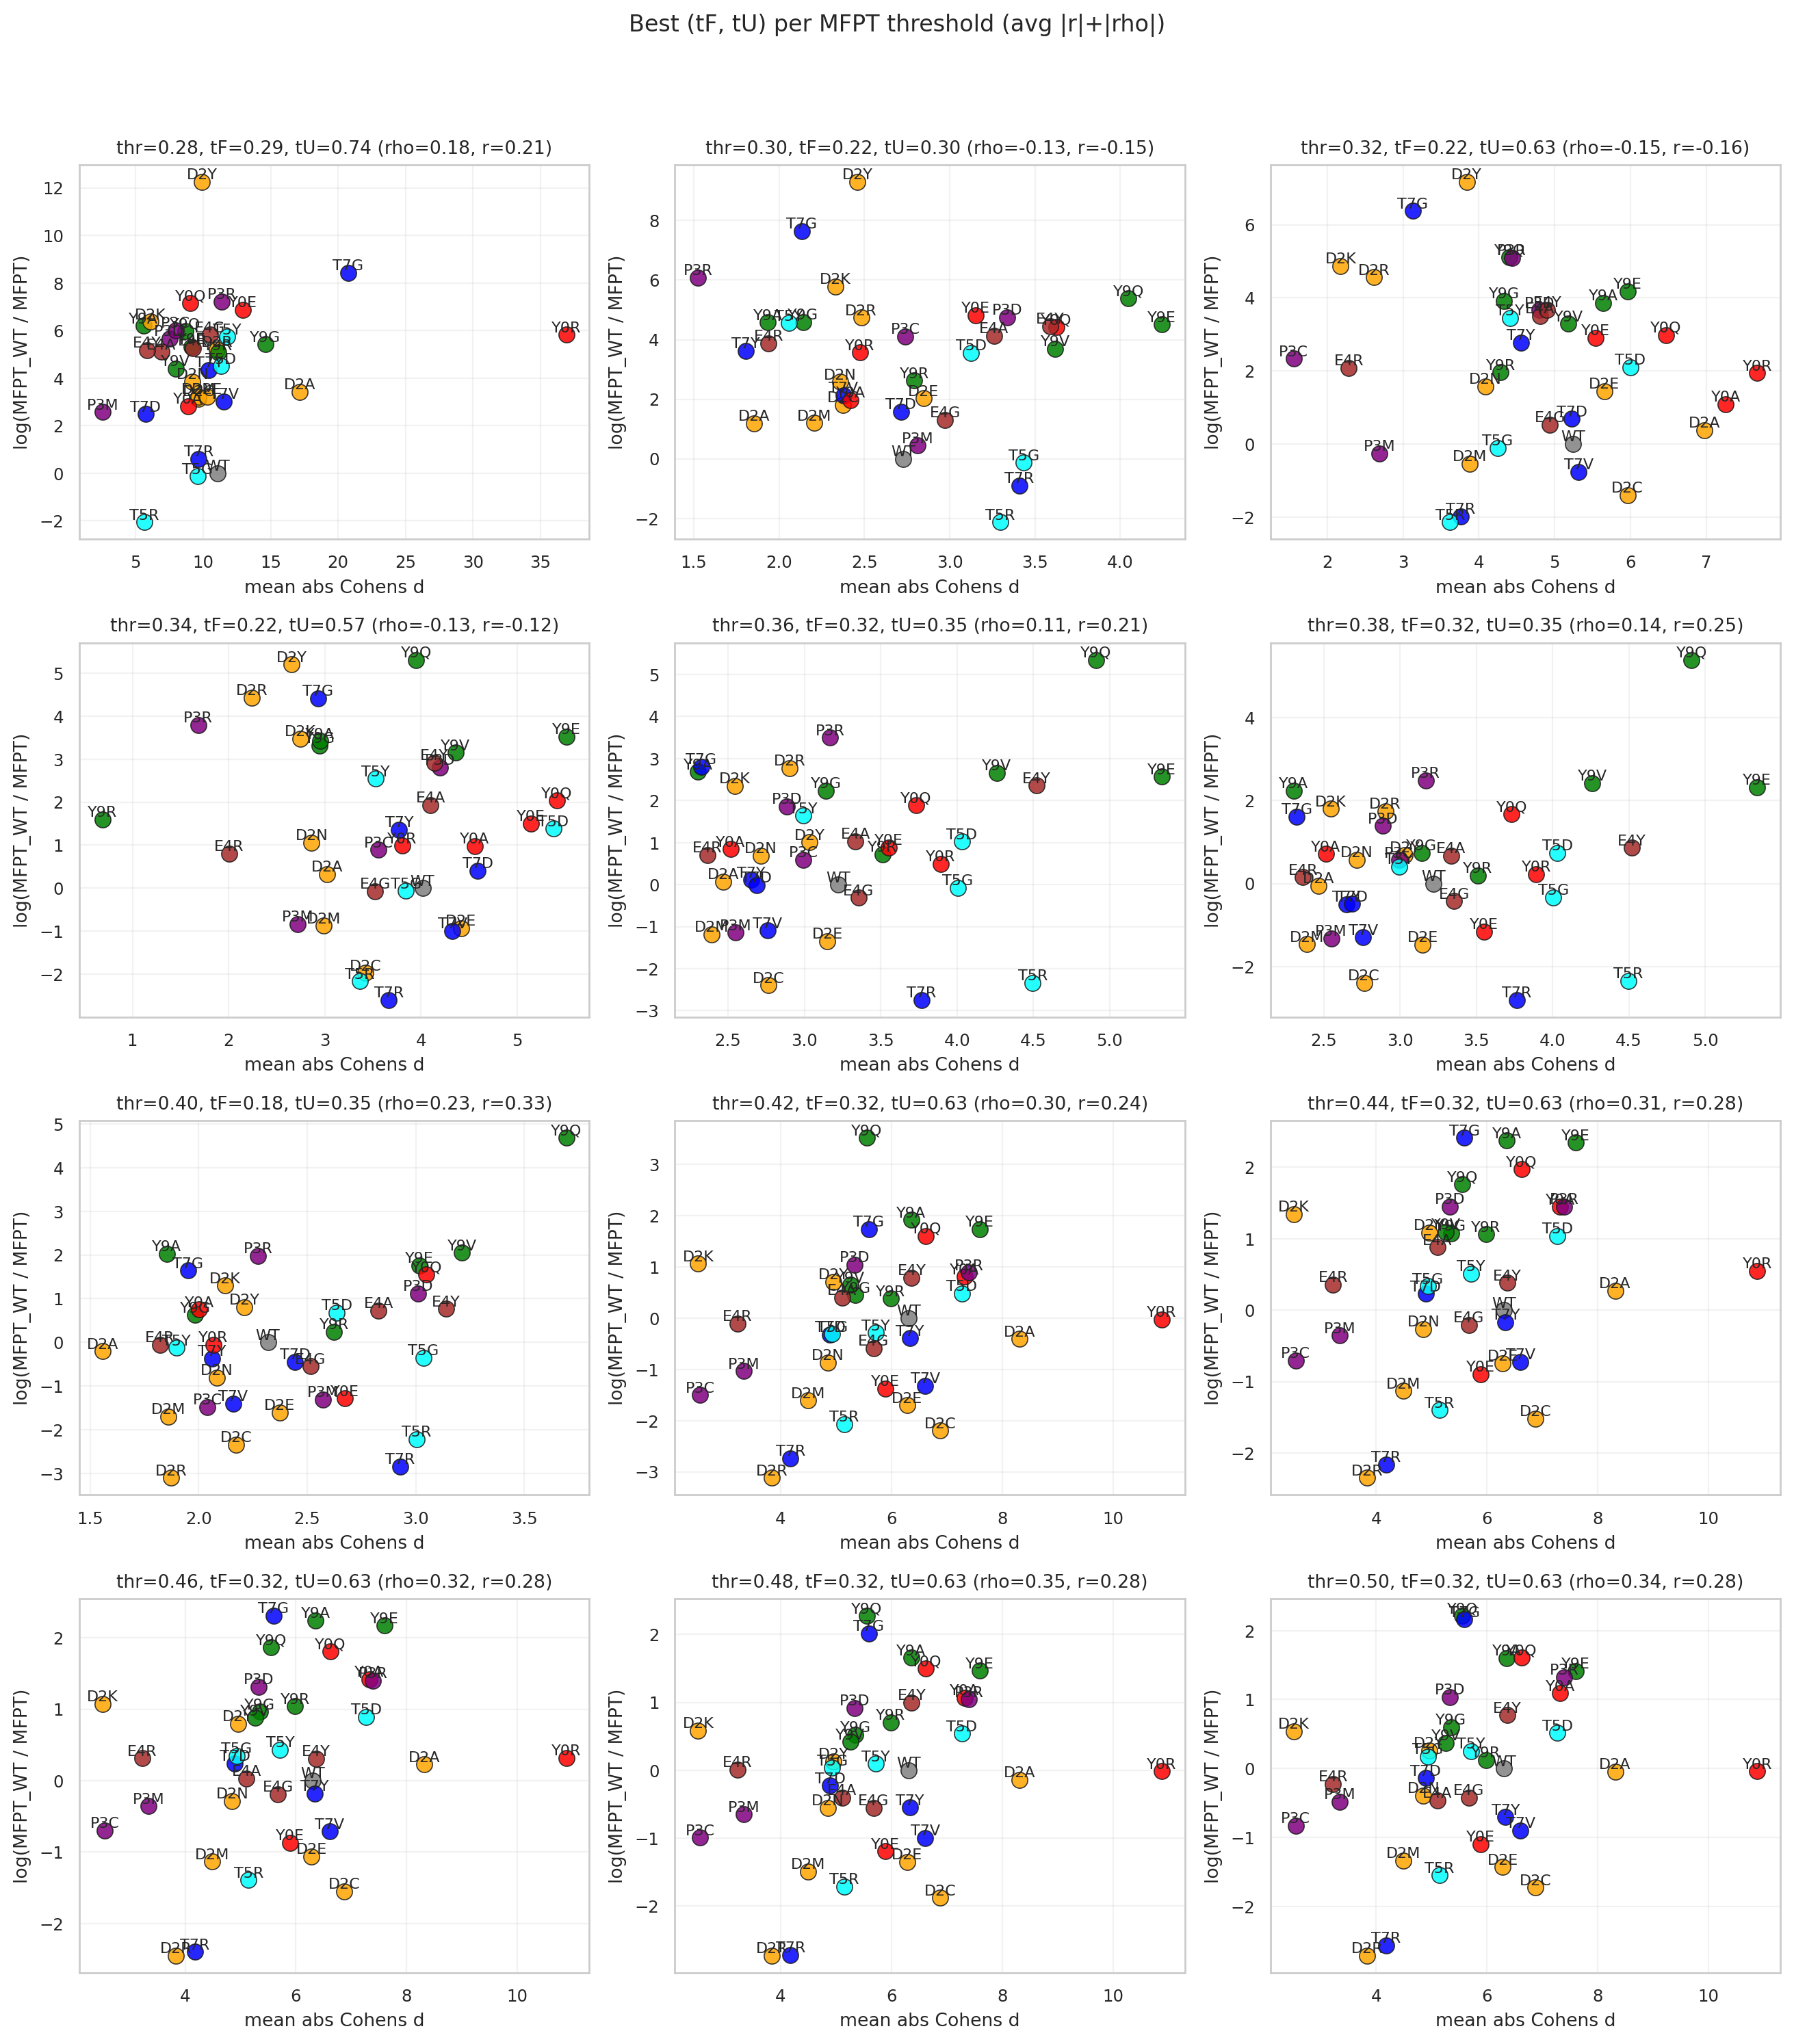

,thr,tF,tU,val,pear,combo
0,0.28,0.29,0.74,0.183784,0.208857,0.196321
1,0.30,0.22,0.30,0.130245,0.147498,0.138871
2,0.32,0.22,0.63,0.145431,0.160483,0.152957
3,0.34,0.22,0.57,0.134620,0.116028,0.125324
4,0.36,0.32,0.35,0.105019,0.210889,0.157954
5,0.38,0.32,0.35,0.138224,0.249401,0.193813
6,0.40,0.18,0.35,0.231660,0.328815,0.280238
7,0.42,0.32,0.63,0.299614,0.244198,0.271906
8,0.44,0.32,0.63,0.314028,0.277635,0.295831
9,0.46,0.32,0.63,0.320463,0.279971,0.300217


In [9]:
ncols = min(3, len(best_rows) if best_rows else 1)
nrows = int(np.ceil(len(best_rows) / ncols)) if best_rows else 1
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.8 * nrows), squeeze=False)
for ax, b in zip(axes.ravel(), best_rows):
    tF = float(b['tF'])
    tU = float(b['tU'])
    thr = float(b['thr'])
    df_thr = mean_cache[(thr, tF, tU)]
    scatter_with_labels(
        ax,
        df_thr,
        'cohen_d',
        'log_mfpt_ratio',
        label_col=None,
        color_col='residue_idx',
        colors=res_colors,
    )
    rho = df_thr['cohen_d'].corr(df_thr['log_mfpt_ratio'], method='spearman')
    pear = df_thr['cohen_d'].corr(df_thr['log_mfpt_ratio'], method='pearson')
    ax.set_title(f"thr={thr:.2f}, tF={tF:.2f}, tU={tU:.2f} (rho={rho:.2f}, r={pear:.2f})")
    ax.set_xlabel("mean abs Cohens d")
    ax.set_ylabel('log(MFPT_WT / MFPT)')
    ax.grid(True, alpha=0.25)

for ax in axes.ravel()[len(best_rows):]:
    ax.axis('off')

fig.suptitle('Best (tF, tU) per MFPT threshold (avg |r|+|rho|)', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

best_df